# Create Chromatin Loops Layouts - Non-Neurons

This notebook extracts loop intensities from Hi-C maps and performs PCA analysis to visualize differences between healthy and schizophrenia samples.

In [ ]:
import pandas as pd
import numpy as np
from itertools import chain
from tqdm import tqdm
import os
from os import listdir
from os.path import isfile, join
import glob
import json
import seaborn as sns
import cooler
import bioframe
import cooltools
from cooltools.lib.numutils import fill_diag
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import matplotlib.pyplot as plt
import warnings
from dotenv import load_dotenv

warnings.simplefilter(action='ignore', category=FutureWarning)
assert os.environ['CONDA_DEFAULT_ENV'] == "hic"

In [6]:
load_dotenv()

path_to_maps = os.getenv("PATH_TO_PROCESSED_MAPS")
path_to_loops = "./loops_cooltools_data/loops_final_files/"
os.listdir(path_to_loops)

['HCM12minus_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_final.bed',
 'SZ08minus_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_final.bed',
 'SZ10minus_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_final.bed',
 'SZ-01minus_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_final.bed',
 'HC-91minus_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_final.bed',
 'HC-318minus_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_final.bed',
 'HC-2Mminus_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_final.bed',
 'HC24minus_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_final.bed',
 'HC-3Mminus_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_final.bed',
 'SZ-03minus_sampled_drop_diag_1kb_dots_final_12000000maxloci_0.13fdr_15000res_small_NaN5_fi

# Get Loops Positions on Hi-C Maps

In [7]:
def get_hg38_arms():
    hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
    hg38_cens = bioframe.fetch_centromeres('hg38')
    hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
    return hg38_arms[hg38_arms.chrom!='chrM'].reset_index(drop=True)
    
def get_loops(map, loops_name, hg38_arms, path_to_save, maps_directory=path_to_maps, loops_plus_directory=path_to_loops,  binzise = 15_000):
    hg38_arms = get_hg38_arms()
    loops_plus = pd.read_csv(f'{loops_plus_directory}/{loops_name}', sep='\t', header=None)
    loops_plus.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2', 'num','kernel_id']
    loops_plus = loops_plus.sort_values(['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']).reset_index(drop=True)
    loops_plus['num'] = [i for i in range(loops_plus.shape[0])]
    
    loops_plus.to_csv(f"{loops_plus_directory}/sorted_loops/{loops_name.split('.bed')[0]}_sorted.bed", sep='\t', index=False)
    name = map.split("/")[-1].split(".")[0]
    
    print(name)
    clr = cooler.Cooler(f'{map}::/resolutions/{binzise}')
    expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=16)
    plus_hc_loops = []        
    stack = cooltools.pileup(clr, 
                             loops_plus, 
                             hg38_arms,                                 
                             expected_df=expected, 
                             flank=200000,
                             nproc=17)
    
    stack[:, :, np.all(stack == 0, axis=(0,1))] = np.nan
    plus_hc_loops.append(stack)     
    np.save(f"{path_to_save}/{name}_20kb_cooltools_loops.npy", plus_hc_loops[0]) 
    assert loops_plus.shape[0] ==  plus_hc_loops[0].shape[0]
    return name, plus_hc_loops[0], loops_plus

def load_loops_back(maps_plus):
    loops = {}
    for map in tqdm(maps_plus):        
        name = map.split("/")[-1].split(".")[0]        
        plus_hc_loops = np.load(f"{path_to_save}/{name}_20kb_cooltools_loops.npy")
        loops[name] = plus_hc_loops   
    return loops

In [15]:
hg38_arms = get_hg38_arms()
binsize = 15_000
path_to_loops_intensities = "./loops_cooltools_data/loops_supporting_files/loops_intensities/"
number_of_files = 12

pattern = '.bed'
not_pattern = '.bedped'
files = [f for f in listdir(path_to_loops) if pattern in f and not_pattern not in f]
files.sort()

pattern = 'mcool'
maps = [path_to_maps+f for f in listdir(path_to_maps) if pattern in f and "minus" in f and "merge." not in f]
maps.sort()
assert len(maps) == number_of_files
assert len(files) == number_of_files

In [13]:
loops = {}
sorted_loops = {}
for map_path, loops_path in maps2loops.items():
    name, loops_prep, loops_plus = get_loops(map_path,loops_path, hg38_arms, path_to_loops_intensities)
    loops[name] = loops_prep
    sorted_loops[name] = loops_plus

HC-2Mminus
HC-318minus
HC-3Mminus
HC-91minus
HC24minus
HCM12minus
SZ-01minus
SZ-03minus
SZ08minus
SZ10minus
SZ20minus
SZ6minus


# Get Intensity in 3x3 Bins

In [16]:
def process_loops(loops, retain_all_values = False):
    first_key = next(iter(loops))  
    len_loops = loops[first_key].shape[0]
    center = (loops[first_key].shape[1] - 1) // 2 
    start_index, end_index = center - 1, center + 2
    collect_min = []
    loops_values = {map_key: {} for map_key in loops}  

    for loop in range(len_loops):
        selected_box, min_length, all_values = process_each_loop(loops, loop, start_index, end_index)
        collect_min.extend([min_length] * len(loops))  

        for i, map_key in enumerate(loops):
            
            if selected_box[i][:min_length] == []:
                appended_value = "NaN"
            else:
                appended_value = np.nanmean(selected_box[i][:min_length])
            if retain_all_values:
                appended_value = all_values[i]
            loops_values[map_key].setdefault(loop, []).append(appended_value)

    for map_key in loops:
        loops_values[map_key] = [value[0] for value in loops_values[map_key].values()]
    return loops_values

def process_each_loop(loops, loop, start_index, end_index):
    selected_box, all_values = [], []
    min_length = 9
    for map_key in loops:
        array = loops[map_key][loop][start_index:end_index, start_index:end_index]
        all_values.append(array)
        cleaned_list = array[~np.isnan(array)].tolist()
        cleaned_list_temp = [i for i in cleaned_list if i!=0]
        if cleaned_list_temp:
            cleaned_list = cleaned_list_temp
        cleaned_list.sort(reverse=True)
        selected_box.append(cleaned_list)
        min_length = min(min_length, len(cleaned_list))
    return selected_box, min_length, all_values


def save_loops(processed_loops_all, data_mean, name_data_all, name_data_mean, path):    
    #alll
    data_all = processed_loops_all.copy()
    for key in data_all:
        data_all[key] = [arr.tolist() for arr in data_all[key]]
    with open(f'{path}/{name_data_all}.json', 'w') as f:
        json.dump(data_all, f)
    
    with open(f'{path}/{name_data_mean}.json', 'w') as f:
        json.dump(data_mean, f)

def get_3_to_3_loops(loops_intensities, name, binzise = 15_000, path= path_to_loops_intensities):
    processed_loops_mean = process_loops(loops_intensities)    
    processed_loops_all = process_loops(loops_intensities, retain_all_values=True)
    
    save_loops(processed_loops_all, processed_loops_mean, f'loops_{name}_20kb_cooltools_loops_3x3bin_all', f'loops_{name}_20kb_cooltools_loops_3x3bin_mean', path)
    return processed_loops_mean, processed_loops_all, loops


In [17]:
processed_loops_mean_MAPS = {}
processed_loops_all_MAPS = {}
for name, loops_one in loops.items():
    one_loop = {}
    one_loop[name] =  loops_one
    processed_loops_mean, processed_loops_all, loops = get_3_to_3_loops(one_loop, name)
    processed_loops_mean_MAPS.update(processed_loops_mean)
    processed_loops_all_MAPS.update(processed_loops_all)

# Merge with Intensity

In [18]:
pattern = '_mean.json'
not_pattern = 'svdv'
files_loops_intensities = [f for f in listdir(path_to_loops_intensities) if pattern in f and not_pattern not in f]
files_loops_intensities.sort()
assert len(files_loops_intensities) == 12

In [19]:
for name in sorted_loops.keys():    
    df = sorted_loops[name]
    df["intensity_all"] = processed_loops_all_MAPS[name]
    df["intensity_mean"] = processed_loops_mean_MAPS[name]
    df.to_csv(f"{path_to_loops_intensities}/{name}_20kb_cooltools_loops_sorted_with_intensity.bed", sep='\t', index=False)
    
print('Done!')

Done!


# Visualize Data with PCA

In [20]:
dfs = {}
for name in sorted_loops.keys():    
    dots_final = pd.read_csv(f"{path_to_loops_intensities}/{name}_20kb_cooltools_loops_sorted_with_intensity.bed", sep='\t')
    dfs[name] = dots_final

In [21]:
df_res_final = pd.DataFrame()
for name  in dfs.keys():
    split_df = dfs[name].set_index(['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2'])[['intensity_mean']]
    split_df.columns = [name]
    df_res_final = pd.concat([df_res_final, split_df], axis=1)
    print(df_res_final.shape[0])

df_res_final.fillna(0, inplace = True)
df_res_final.reset_index(inplace = True)
df_res_final = df_res_final[~df_res_final.chrom1.isin(["chrX","chrY", 'chrM'])]
print(df_res_final.shape[0])


2991
3941
4865
5831
7179
9134
10242
10376
11363
11691
12846
14410
14410


In [22]:
df_columns = df_res_final.columns.tolist()[6:]
prep_df = df_res_final[df_res_final.columns.tolist()[6:]].T.reset_index().fillna(0)
X = prep_df[prep_df.columns.tolist()[1:]]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
pca = PCA(n_components=6)
components = pca.fit_transform(X_train_scaled)

components_df = pd.DataFrame(components, columns = ["PC1","PC2","PC3","PC4","PC5","PC6"])
components_df["sample"] =df_res_final.T.reset_index()["index"].tolist()[6:]

group = []
for i in df_columns :
    if 'HC' in i:
        group.append('Healthy')
    
    else:
        group.append('SZ')
assert len(group) == len(df_columns) 
components_df['group'] = group    

components_df['sample_simple'] =df_res_final.T.reset_index()["index"].tolist()[6:]    


In [23]:
def abline(slope, intercept):
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')
    
def plot_pca(pca, components_df, compontents):
    sns.set_style("white")
    plt.figure(figsize=(11,11)) 
    hue='group'
    my_pal = {"Healthy": (sns.color_palette('deep')[8]),
          "SZ": (sns.color_palette('deep')[4])}
    
    sns.scatterplot(data=components_df, 
                    s=120, x=compontents[0], y=compontents[1], 
                    hue=hue, palette = my_pal)
    abline(0, 0)    
    plt.axvline(0, 0,300, ls = '--', c = "lightgrey")
    plt.axhline(0, 0,300, ls = '--', c = "lightgrey")
    plt.legend(frameon=True, loc='best')
    PCA_order = {"PC1":0, "PC2":1, "PC3":2}
    plt.xlabel(f"{compontents[0]} {round(pca.explained_variance_ratio_[PCA_order[compontents[0]]].round(3)*100,1)}%")
    plt.ylabel(f"{compontents[1]} {round(pca.explained_variance_ratio_[PCA_order[compontents[1]]].round(3)*100,1)}%")
    
    texts = [plt.text(components_df[compontents[0]][line], components_df[compontents[1]][line], components_df["sample_simple"][line], horizontalalignment='left',
                  size='small', color='black')
             for line in range(0,components_df.shape[0])]
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=0.4))
    plt.show()

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


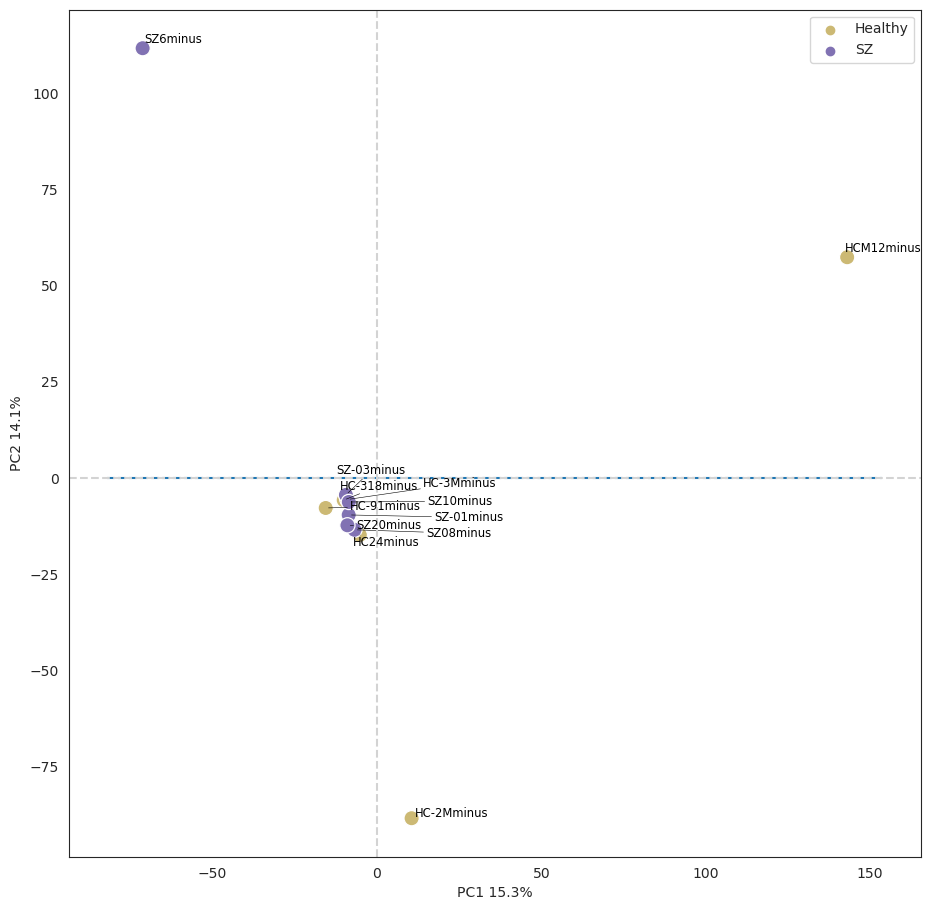

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


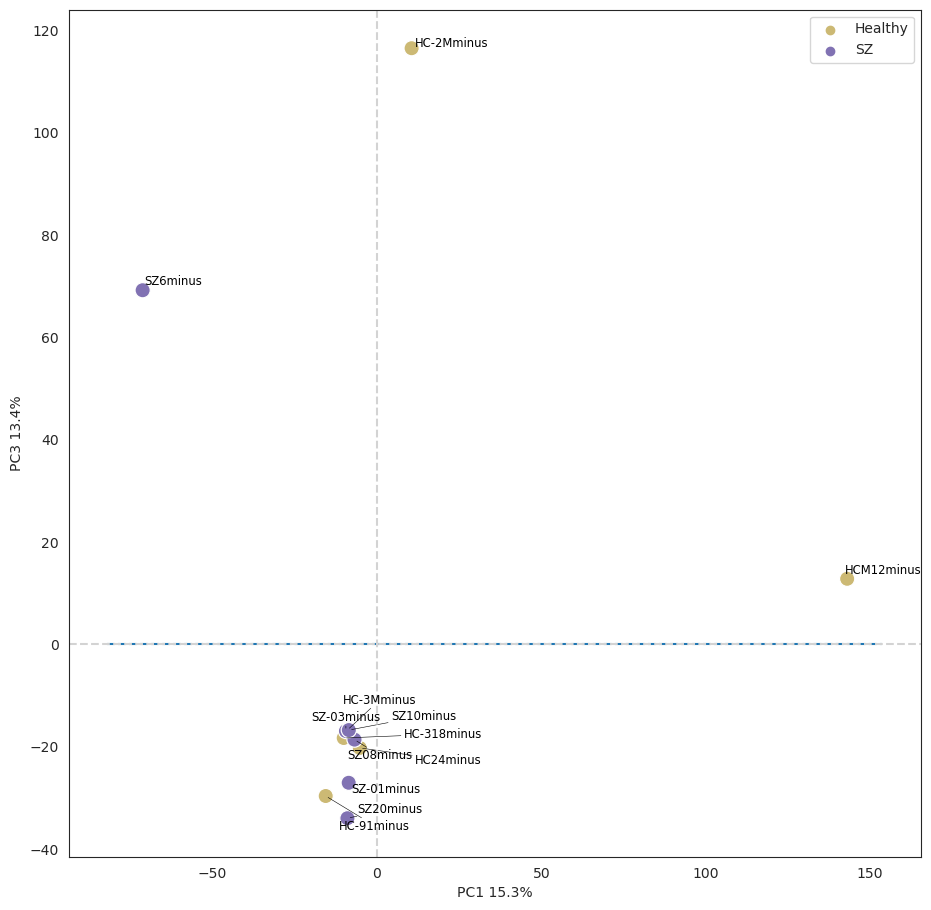

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


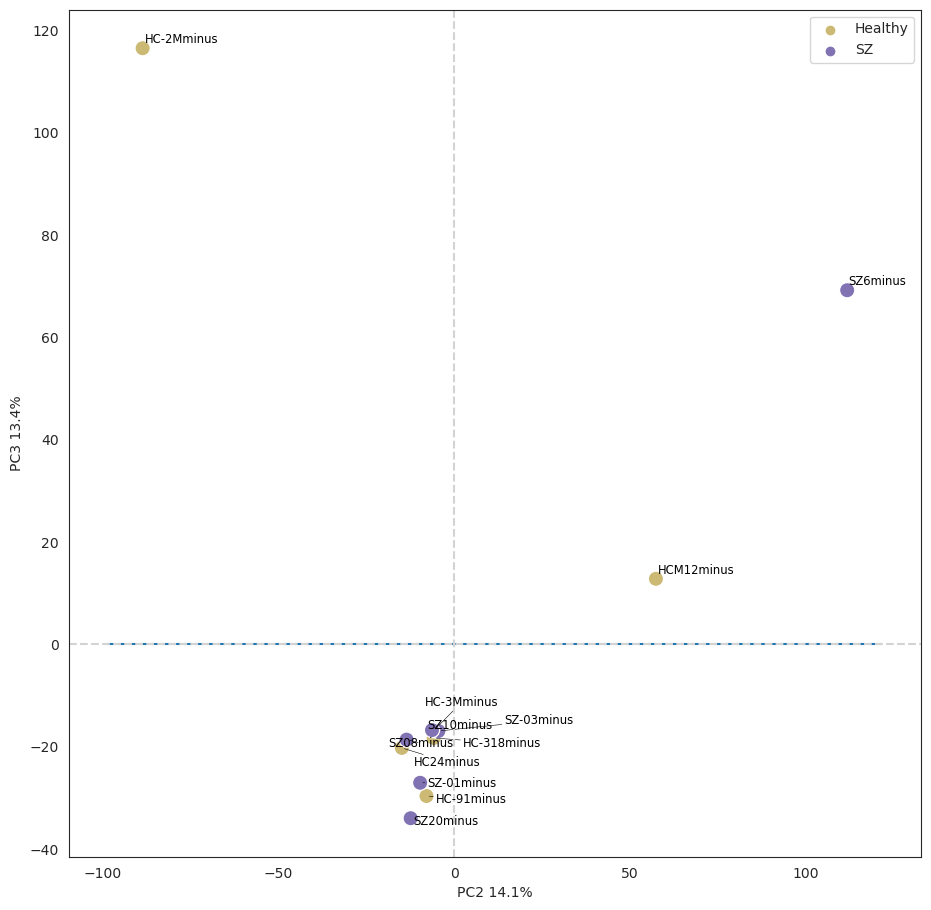

In [24]:
for pca_sel in [['PC1','PC2'], ['PC1','PC3'],['PC2','PC3']]:
    plot_pca(pca, components_df, pca_sel)